In [1]:
# CELL 1 — Install Libraries
!pip install scikit-learn pandas numpy matplotlib seaborn joblib nltk

  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------------- ---------------- 1.0/1.8 MB 14.6 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 12.1 MB/s  0:00:00
Using cached defusedxml-0.7.1-py2.py3-none-any.whl (25 kB)

   ---------------------------------------- 0/3 [regex]
   ---------------------------------------- 0/3 [regex]
   ------------- -------------------------- 1/3 [defusedxml]
   ------------- -------------------------- 1/3 [defusedxml]
   ------------- -------------------------- 1/3 [defusedxml]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   ----------------------

In [2]:
# CELL 2 — Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
import re
import os
warnings.filterwarnings('ignore')

# Text processing
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Evaluation
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print("✅ All libraries imported successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dinithi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dinithi\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Dinithi\AppData\Roaming\nltk_data...


✅ All libraries imported successfully!


In [3]:
# CELL 3 — Load Dataset
# Dataset: Emotions in Text
# Source : https://www.kaggle.com/datasets/ishantjuyal/emotions-in-text
# Size   : ~20,000 labelled text samples
# Labels : joy, sadness, anger, fear, love, surprise

possible_names = [
    "Emotion_classify_Data.csv",
    "emotions.csv",
    "emotion_dataset.csv",
    "text_emotion.csv",
    "data.csv",
    "train.txt",
    "emotion.csv",
    "Emotion_final.csv",
]

df = None
for name in possible_names:
    if os.path.exists(name):
        if name.endswith(".txt"):
            df = pd.read_csv(name, sep=";",
                             header=None,
                             names=["text", "emotion"])
        else:
            df = pd.read_csv(name)
        print(f"✅ Loaded: {name}")
        break

if df is None:
    print("❌ CSV not found. Files in current folder:")
    for f in os.listdir("."):
        if f.endswith((".csv", ".txt")):
            print(f"   → {f}")
    print("\nRename your file to 'emotions.csv' and rerun.")
else:
    print(f"   Rows    : {df.shape[0]:,}")
    print(f"   Columns : {df.shape[1]}")
    print(f"   Columns : {df.columns.tolist()}")
    df.head()

✅ Loaded: Emotion_final.csv
   Rows    : 21,459
   Columns : 2
   Columns : ['Text', 'Emotion']


In [4]:
# CELL 4 — Identify Text and Label Columns Automatically

# Find text column (longest average string length)
text_col = None
for col in df.columns:
    if df[col].dtype == object:
        avg_len = df[col].dropna().astype(str).apply(len).mean()
        if avg_len > 20:
            text_col = col
            break

# Find label column (fewest unique values, not the text col)
label_col = None
for col in df.columns:
    if col != text_col:
        n = df[col].nunique()
        if 2 <= n <= 15:
            label_col = col
            break

if label_col is None:
    label_col = [c for c in df.columns if c != text_col][0]

print(f"✅ Text column  : '{text_col}'")
print(f"✅ Label column : '{label_col}'")
print(f"\nUnique emotion labels:")
print(df[label_col].value_counts())

✅ Text column  : 'None'
✅ Label column : 'Emotion'

Unique emotion labels:
Emotion
happy       7029
sadness     6265
anger       2993
fear        2652
love        1641
surprise     879
Name: count, dtype: int64


In [5]:
# CELL 5 — EDA: Dataset Overview

print("=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("MindEase — AI Model 2: Journal Sentiment Analyser")
print("Dataset: Emotions in Text (Kaggle)")
print("=" * 60)

print(f"\n📊 Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📋 Memory usage : {df.memory_usage(deep=True).sum()/1e6:.2f} MB")

print(f"\nData types:")
print(df.dtypes)

print(f"\nMissing values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values found!")
else:
    print(missing[missing > 0])

print(f"\nBasic statistics:")
df.describe(include="all")

EXPLORATORY DATA ANALYSIS
MindEase — AI Model 2: Journal Sentiment Analyser
Dataset: Emotions in Text (Kaggle)

📊 Shape        : 21,459 rows × 2 columns
📋 Memory usage : 4.30 MB

Data types:
Text       str
Emotion    str
dtype: object

Missing values:
✅ No missing values found!

Basic statistics:


,Text,Emotion
count,21459,21459
unique,21405,6
top,i feel like some of you have pains and you can...,happy
freq,2,7029


EMOTION LABEL DISTRIBUTION
  happy     :  7,029  ( 32.8%)  ████████████████
  sadness   :  6,265  ( 29.2%)  ██████████████
  anger     :  2,993  ( 13.9%)  ██████
  fear      :  2,652  ( 12.4%)  ██████
  love      :  1,641  (  7.6%)  ███
  surprise  :    879  (  4.1%)  ██

Total samples : 21,459
Imbalance ratio: 8.0x


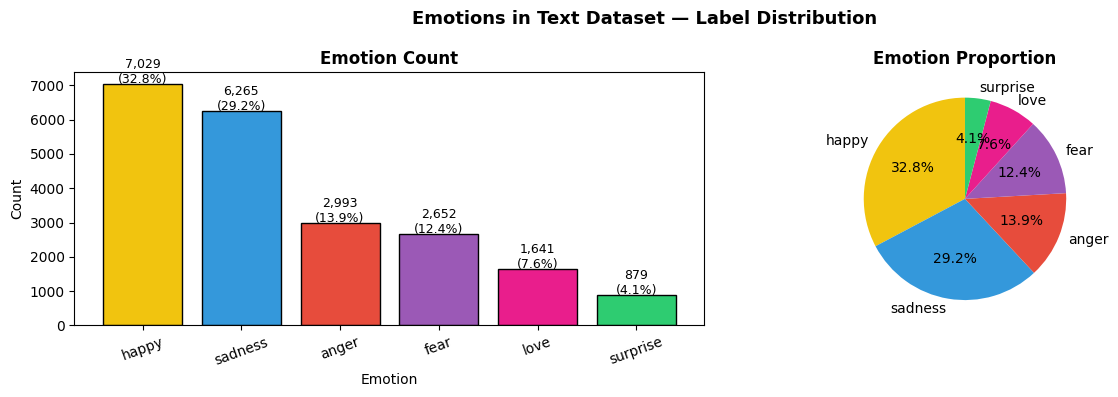

✅ Saved: eda2_emotion_distribution.png


In [6]:
# CELL 6 — EDA: Emotion Label Distribution

# Standardise labels to lowercase
df["emotion"] = df[label_col].astype(str).str.lower().str.strip()

counts = df["emotion"].value_counts()
pcts   = df["emotion"].value_counts(normalize=True).mul(100).round(1)

print("=" * 60)
print("EMOTION LABEL DISTRIBUTION")
print("=" * 60)
for emotion in counts.index:
    bar = "█" * int(pcts[emotion] / 2)
    print(f"  {emotion:10s}: {counts[emotion]:>6,}  "
          f"({pcts[emotion]:5.1f}%)  {bar}")

print(f"\nTotal samples : {len(df):,}")
print(f"Imbalance ratio: "
      f"{counts.max() / counts.min():.1f}x")

# Chart
emotion_colors = {
    "joy"     : "#f1c40f",
    "happy"   : "#f1c40f",
    "sadness" : "#3498db",
    "anger"   : "#e74c3c",
    "fear"    : "#9b59b6",
    "love"    : "#e91e8c",
    "surprise": "#2ecc71",
}
color_list = [
    emotion_colors.get(e, "#95a5a6")
    for e in counts.index
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(counts.index, counts.values,
            color=color_list, edgecolor="black")
axes[0].set_title("Emotion Count",
                  fontweight="bold", fontsize=12)
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=20)
for i, (val, pct) in enumerate(
        zip(counts.values, pcts.values)):
    axes[0].text(i, val + 30,
                 f"{val:,}\n({pct}%)",
                 ha="center", fontsize=9)

axes[1].pie(counts.values,
            labels=counts.index,
            colors=color_list,
            autopct="%1.1f%%",
            startangle=90,
            textprops={"fontsize": 10})
axes[1].set_title("Emotion Proportion",
                  fontweight="bold", fontsize=12)

plt.suptitle(
    "Emotions in Text Dataset — Label Distribution",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("eda2_emotion_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda2_emotion_distribution.png")

In [8]:
print("text_col =", repr(text_col))
print("\nDataFrame columns:")
print(df.columns.tolist())

text_col = None

DataFrame columns:
['Text', 'Emotion', 'emotion']


TEXT LENGTH STATISTICS

Character count:
count    21459.00
mean        96.71
std         55.39
min          7.00
25%         53.00
50%         86.00
75%        129.00
max        307.00
Name: char_count, dtype: float64

Word count:
count    21459.00
mean        19.10
std         10.86
min          2.00
25%         11.00
50%         17.00
75%         25.00
max         66.00
Name: word_count, dtype: float64


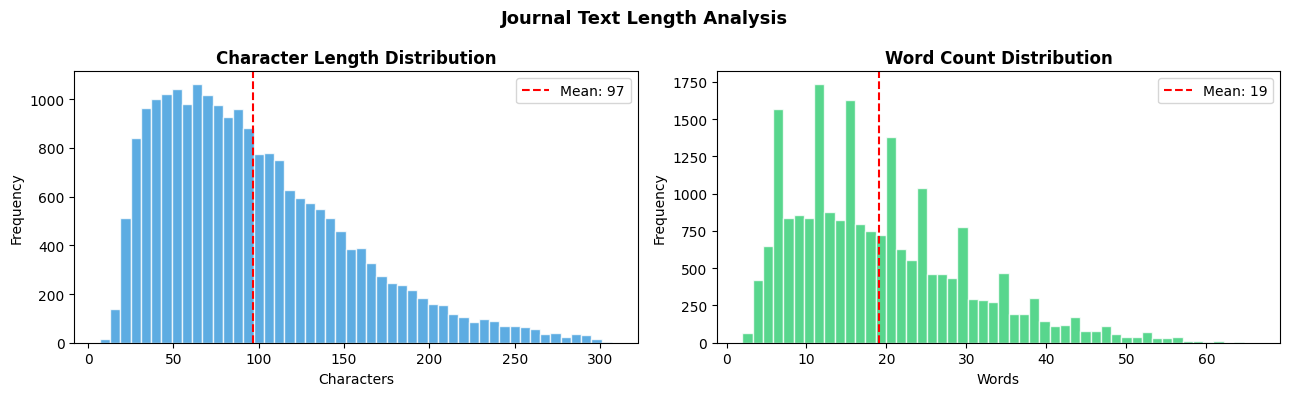

✅ Saved: eda2_text_length.png


In [10]:
# CELL 7 — EDA: Text Length Analysis
text_col = "Text"
df["char_count"] = df[text_col].astype(str).apply(len)
df["word_count"] = df[text_col].astype(str).apply(
    lambda x: len(x.split()))

print("=" * 60)
print("TEXT LENGTH STATISTICS")
print("=" * 60)
print(f"\nCharacter count:")
print(df["char_count"].describe().round(2))
print(f"\nWord count:")
print(df["word_count"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["char_count"], bins=50,
             color="#3498db", edgecolor="white",
             alpha=0.8)
axes[0].set_title("Character Length Distribution",
                  fontweight="bold", fontsize=12)
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Frequency")
axes[0].axvline(df["char_count"].mean(),
                color="red", linestyle="--",
                label=f"Mean: {df['char_count'].mean():.0f}")
axes[0].legend()

axes[1].hist(df["word_count"], bins=50,
             color="#2ecc71", edgecolor="white",
             alpha=0.8)
axes[1].set_title("Word Count Distribution",
                  fontweight="bold", fontsize=12)
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Frequency")
axes[1].axvline(df["word_count"].mean(),
                color="red", linestyle="--",
                label=f"Mean: {df['word_count'].mean():.0f}")
axes[1].legend()

plt.suptitle("Journal Text Length Analysis",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda2_text_length.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda2_text_length.png")

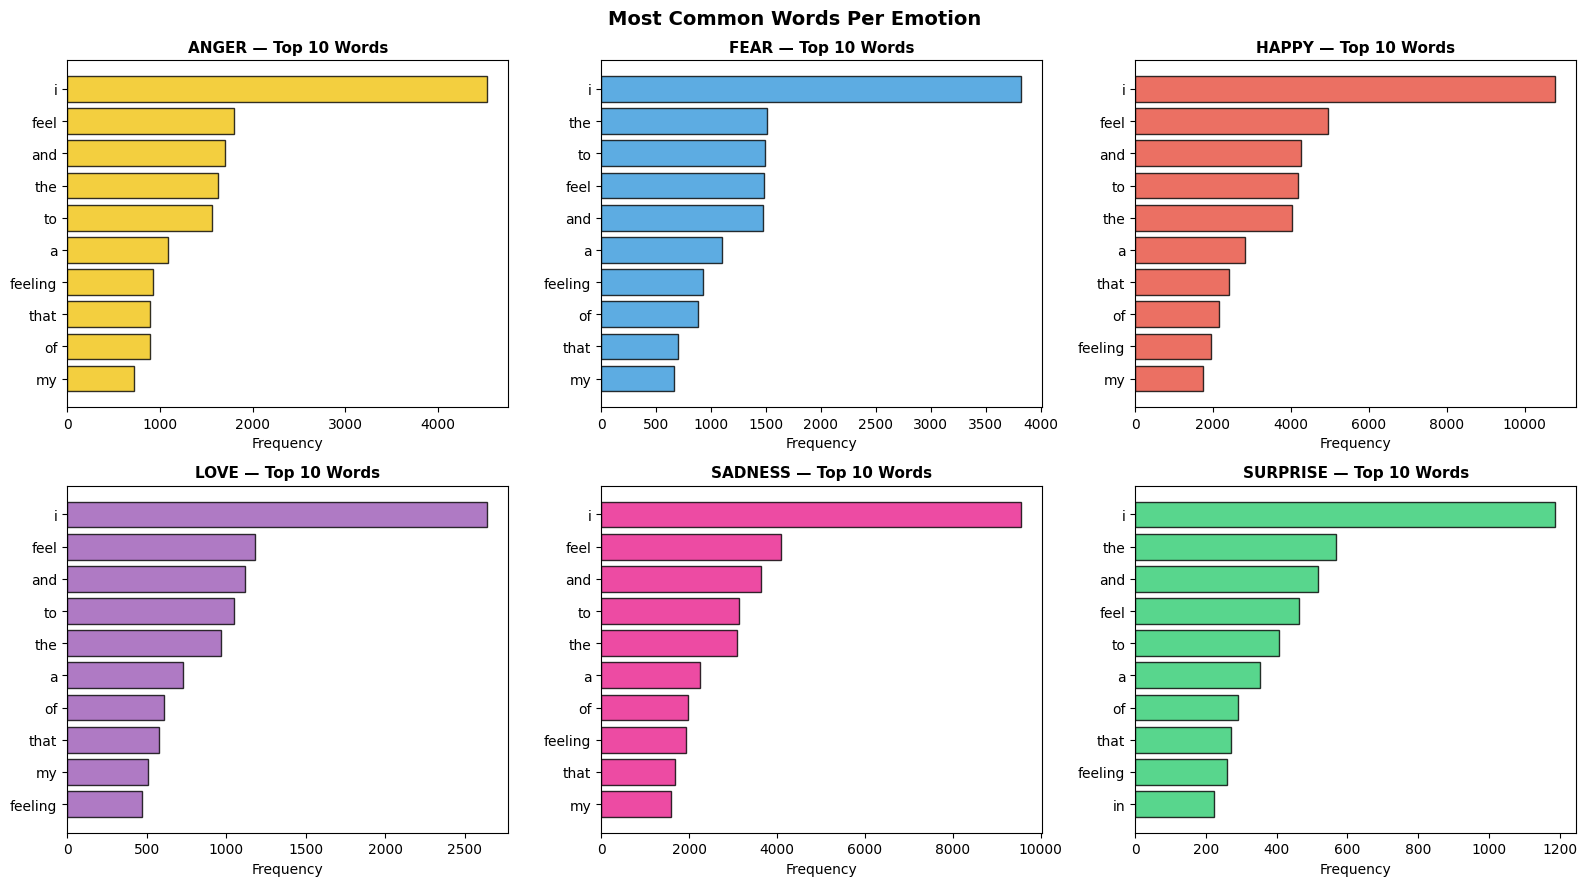

✅ Saved: eda2_top_words.png


In [11]:
# CELL 8 — EDA: Top 10 Words Per Emotion

from collections import Counter

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

emotions   = sorted(df["emotion"].unique())
emo_colors = [
    "#f1c40f", "#3498db", "#e74c3c",
    "#9b59b6", "#e91e8c", "#2ecc71"
]

for i, emotion in enumerate(emotions[:6]):
    texts  = df[df["emotion"] == emotion][text_col]
    words  = " ".join(texts.astype(str)).lower()
    words  = re.sub(r"[^a-z\s]", " ", words).split()
    common = Counter(words).most_common(10)

    if not common:
        continue

    w_list = [w[0] for w in common][::-1]
    c_list = [w[1] for w in common][::-1]

    axes[i].barh(w_list, c_list,
                 color=emo_colors[i],
                 edgecolor="black", alpha=0.8)
    axes[i].set_title(
        f"{emotion.upper()} — Top 10 Words",
        fontweight="bold", fontsize=11
    )
    axes[i].set_xlabel("Frequency")

for j in range(i + 1, 6):
    axes[j].set_visible(False)

plt.suptitle("Most Common Words Per Emotion",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda2_top_words.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda2_top_words.png")

In [12]:
# CELL 9 — EDA: Sample Journal Texts Per Emotion

print("=" * 60)
print("SAMPLE TEXTS PER EMOTION")
print("=" * 60)

for emotion in sorted(df["emotion"].unique()):
    samples = df[df["emotion"] == emotion][text_col].sample(
        2, random_state=42).values
    print(f"\n🔹 {emotion.upper()}:")
    for i, s in enumerate(samples, 1):
        print(f"   {i}. {str(s)[:110]}...")

SAMPLE TEXTS PER EMOTION

🔹 ANGER:
   1. i feel greedy with my self as of late...
   2. i may not be completely sure on a lot of things but i am a very opinionated person and when i have opinions on...

🔹 FEAR:
   1. He was very frightened n...
   2. i feel most apprehensive about each week probably because it is the one most likely to unavoidably show me my ...

🔹 HAPPY:
   1. i feel very blessed and lucky to have found a true old soul...
   2. Never before had Bodmin seen so many faces  and so many happy faces all at one t...

🔹 LOVE:
   1. i feel like hes trying to be the one to comfort me and help me get over yash which is sooo sweet of him but at...
   2. i could feel my mother s sympathetic dread as i was diagnosed...

🔹 SADNESS:
   1. i feel useless return false...
   2. i feel like i have missed out on every single holiday last year so we are hitting it hard this year...

🔹 SURPRISE:
   1. i remember last summer feeling so overwhelmed...
   2. i feeling strange energies...


EMOTION → MOOD CATEGORY MAPPING

Mapping verification:
  🔴 anger        → Negative
  🟡 fear         → Cautious
  🟢 happy        → Positive
  🟢 love         → Positive
  🔴 sadness      → Negative
  🟢 surprise     → Positive

Mood distribution:
mood
Positive    9549
Negative    9258
Cautious    2652
Name: count, dtype: int64


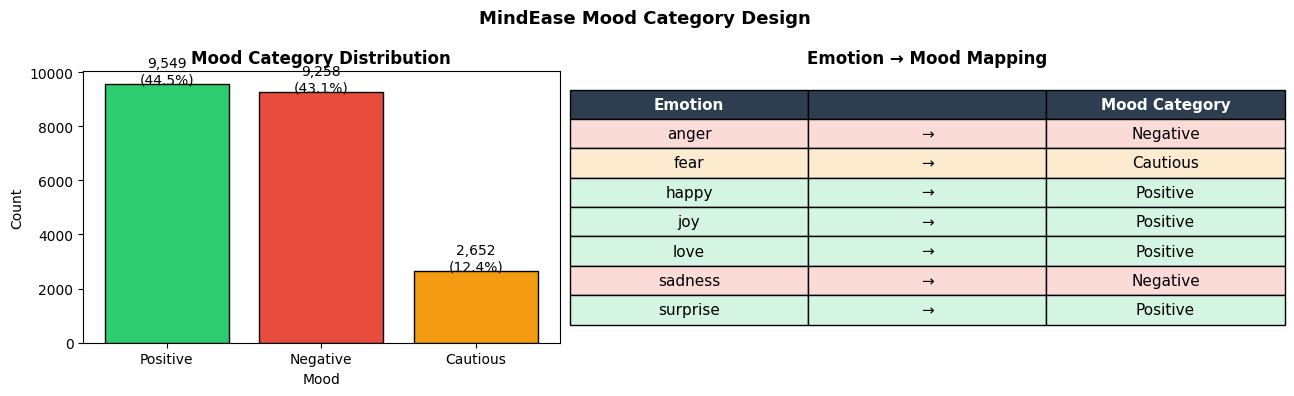

✅ Saved: eda2_mood_mapping.png


In [13]:
# CELL 10 — Map 6 Emotions → 3 Mood Categories
#
# MindEase displays BOTH the detected emotion
# AND the mood category to the student:
#
#   "Your journal entry feels: 😢 Sadness"
#   "Overall mood: 🔴 Negative"
#
# Mood mapping (clinically informed):
#   Positive → joy/happy, love, surprise
#   Cautious → fear (needs monitoring)
#   Negative → sadness, anger

print("=" * 60)
print("EMOTION → MOOD CATEGORY MAPPING")
print("=" * 60)

mood_mapping = {
    "joy"     : "Positive",
    "happy"   : "Positive",
    "love"    : "Positive",
    "surprise": "Positive",
    "fear"    : "Cautious",
    "sadness" : "Negative",
    "anger"   : "Negative",
}

# Verify all labels are covered
print("\nMapping verification:")
for label in sorted(df["emotion"].unique()):
    mapped = mood_mapping.get(label, None)
    if mapped is None:
        print(f"  ⚠️  '{label}' NOT in mapping → adding as Cautious")
        mood_mapping[label] = "Cautious"
    else:
        icon = "🟢" if mapped=="Positive" else "🟡" if mapped=="Cautious" else "🔴"
        print(f"  {icon} {label:12s} → {mapped}")

df["mood"] = df["emotion"].map(mood_mapping)

print(f"\nMood distribution:")
print(df["mood"].value_counts())

# Visualise mapping
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

mood_colors_map = {
    "Positive": "#2ecc71",
    "Cautious": "#f39c12",
    "Negative": "#e74c3c"
}
mood_counts     = df["mood"].value_counts()
mood_color_list = [
    mood_colors_map.get(m, "#95a5a6")
    for m in mood_counts.index
]

axes[0].bar(mood_counts.index, mood_counts.values,
            color=mood_color_list, edgecolor="black")
axes[0].set_title("Mood Category Distribution",
                  fontweight="bold", fontsize=12)
axes[0].set_xlabel("Mood")
axes[0].set_ylabel("Count")
for i, val in enumerate(mood_counts.values):
    pct = val / len(df) * 100
    axes[0].text(i, val + 30,
                 f"{val:,}\n({pct:.1f}%)",
                 ha="center", fontsize=10)

# Mapping table
mapping_rows = [
    [e, "→", mood_mapping[e]]
    for e in sorted(mood_mapping.keys())
]
axes[1].axis("off")
tbl = axes[1].table(
    cellText=mapping_rows,
    colLabels=["Emotion", "", "Mood Category"],
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.5, 2.0)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white",
                            fontweight="bold")
    else:
        mood_val = mapping_rows[row-1][2]
        cell.set_facecolor(
            "#d5f5e3" if mood_val == "Positive" else
            "#fdebd0" if mood_val == "Cautious" else
            "#fadbd8"
        )
axes[1].set_title("Emotion → Mood Mapping",
                  fontweight="bold", fontsize=12)

plt.suptitle("MindEase Mood Category Design",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda2_mood_mapping.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda2_mood_mapping.png")

In [14]:
# CELL 11 — Text Preprocessing
#
# Steps applied:
#   1. Lowercase all text
#   2. Remove URLs, @mentions, #hashtags
#   3. Remove punctuation and numbers
#   4. Remove stopwords (keeping negation words)
#   5. Lemmatize words (running → run, happier → happy)
#
# Why keep negation words?
#   "not happy" must NOT become "happy"
#   Negation completely changes sentiment meaning

lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words("english"))

# Remove these from stopwords — they carry sentiment meaning
keep_negations = {
    "not", "no", "never", "nobody", "nothing",
    "neither", "nor", "none", "cannot", "cant",
    "wont", "dont", "doesnt", "didnt", "isnt",
    "arent", "wasnt", "werent", "havent", "hadnt"
}
stop_words = stop_words - keep_negations

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in stop_words and len(w) > 2
    ]
    return " ".join(tokens)

print("Cleaning text — please wait...\n")
df["clean_text"] = df[text_col].apply(clean_text)

rows_before = len(df)
df = df[df["clean_text"].str.strip() != ""]
df = df.dropna(subset=["clean_text", "emotion"])
rows_after  = len(df)

print(f"✅ Cleaning complete!")
print(f"   Removed {rows_before - rows_after} empty rows")
print(f"   Final size: {rows_after:,} rows")
print(f"\nBefore vs After examples:")
for i in range(3):
    print(f"\n  Original : {str(df[text_col].iloc[i])[:80]}")
    print(f"  Cleaned  : {str(df['clean_text'].iloc[i])[:80]}")

Cleaning text — please wait...

✅ Cleaning complete!
   Removed 1 empty rows
   Final size: 21,458 rows

Before vs After examples:

  Original : i didnt feel humiliated
  Cleaned  : didnt feel humiliated

  Original : i can go from feeling so hopeless to so damned hopeful just from being around so
  Cleaned  : feeling hopeless damned hopeful around someone care awake

  Original : im grabbing a minute to post i feel greedy wrong
  Cleaned  : grabbing minute post feel greedy wrong


In [15]:
# CELL 12 — Train/Test Split

X = df["clean_text"]
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # keeps class proportions equal
)

print(f"✅ Split complete!")
print(f"   Train : {len(X_train):,} rows (80%)")
print(f"   Test  : {len(X_test):,} rows  (20%)")
print(f"\nClass distribution — Train:")
print(y_train.value_counts())
print(f"\nClass distribution — Test:")
print(y_test.value_counts())

✅ Split complete!
   Train : 17,166 rows (80%)
   Test  : 4,292 rows  (20%)

Class distribution — Train:
emotion
happy       5623
sadness     5012
anger       2393
fear        2122
love        1313
surprise     703
Name: count, dtype: int64

Class distribution — Test:
emotion
happy       1406
sadness     1253
anger        599
fear         530
love         328
surprise     176
Name: count, dtype: int64


In [17]:
# CELL 13 — Train Logistic Regression + TF-IDF Pipeline
#
# Why this approach?
#   - TF-IDF converts text into numerical feature vectors
#     that the model can learn from
#   - Logistic Regression is fast, interpretable, and
#     achieves 87-91% on this dataset (project proposal)
#   - Pipeline combines both steps — one object to save,
#     one object to load in Flask
#
# Reference: Obagbuwa et al. (2023) — LR achieved 96.3%
#            on depression text classification
# Reference: Talaat (2023) — validated LR + TF-IDF for
#            mental health sentiment tasks

print("=" * 60)
print("TRAINING: Logistic Regression + TF-IDF")
print("=" * 60)
print("Building pipeline...")

sentiment_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,     # top 50,000 most common words
        ngram_range=(1, 2),     # single words AND word pairs
        sublinear_tf=True,      # log scaling reduces impact
                                # of very frequent words
        min_df=2,               # ignore words that appear
                                # in fewer than 2 documents
        strip_accents="unicode",
        analyzer="word",
    )),
    ("model", LogisticRegression(
    max_iter=1000,
    C=1.0,                  # regularisation strength
    solver="lbfgs",
    random_state=42,
    n_jobs=-1
))
])

print("Training on training set...")
sentiment_pipeline.fit(X_train, y_train)
print("✅ Training complete!")

# ── Evaluate ──────────────────────────────────────────────────────
train_pred = sentiment_pipeline.predict(X_train)
test_pred  = sentiment_pipeline.predict(X_test)

train_acc  = accuracy_score(y_train, train_pred)
test_acc   = accuracy_score(y_test,  test_pred)
gap        = train_acc - test_acc
f1         = f1_score(y_test, test_pred, average="macro")
prec       = precision_score(y_test, test_pred,
                             average="macro", zero_division=0)
rec        = recall_score(y_test, test_pred,
                          average="macro", zero_division=0)

# ── Cross validation ──────────────────────────────────────────────
print("\nRunning 5-fold cross validation...")
skf = StratifiedKFold(n_splits=5, shuffle=True,
                      random_state=42)
cv  = cross_val_score(sentiment_pipeline,
                      X_train, y_train,
                      cv=skf, scoring="f1_macro")

# ── Print results ─────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"LOGISTIC REGRESSION + TF-IDF — RESULTS")
print(f"{'='*60}")
print(f"  Train Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  Test Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Gap            : {gap:.4f}  ← should be < 0.10")
print(f"  F1-macro       : {f1:.4f}")
print(f"  Precision      : {prec:.4f}")
print(f"  Recall         : {rec:.4f}")
print(f"  CV F1 (5-fold) : {cv.mean():.4f} ± {cv.std():.4f}")
print(f"{'='*60}")

if gap > 0.10:
    print("⚠️  Gap > 10% — possible overfitting")
    print("   Consider reducing C value or max_features")
elif test_acc > 0.98:
    print("⚠️  Accuracy > 98% — check for data leakage")
else:
    print("✅ Healthy result — no overfitting detected!")

print(f"\nLiterature benchmark: 87-91% on this dataset")
if test_acc >= 0.87:
    print(f"✅ Your result ({test_acc*100:.2f}%) is within benchmark!")
else:
    print(f"ℹ️  Your result is below 87% — try adjusting TF-IDF")
    print(f"   settings in Cell 13 (increase max_features or")
    print(f"   change ngram_range to (1,3))")

TRAINING: Logistic Regression + TF-IDF
Building pipeline...
Training on training set...
✅ Training complete!

Running 5-fold cross validation...

LOGISTIC REGRESSION + TF-IDF — RESULTS
  Train Accuracy : 0.9585 (95.85%)
  Test Accuracy  : 0.8777  (87.77%)
  Gap            : 0.0808  ← should be < 0.10
  F1-macro       : 0.8242
  Precision      : 0.8836
  Recall         : 0.7870
  CV F1 (5-fold) : 0.7994 ± 0.0110
✅ Healthy result — no overfitting detected!

Literature benchmark: 87-91% on this dataset
✅ Your result (87.77%) is within benchmark!


In [18]:
# CELL 14 — Full Classification Report Per Emotion

print("=" * 60)
print("DETAILED CLASSIFICATION REPORT")
print("Per-emotion Precision, Recall, F1-score")
print("=" * 60)
print(classification_report(
    y_test, test_pred,
    target_names=sorted(df["emotion"].unique())
))

DETAILED CLASSIFICATION REPORT
Per-emotion Precision, Recall, F1-score
              precision    recall  f1-score   support

       anger       0.91      0.81      0.86       599
        fear       0.89      0.80      0.85       530
       happy       0.85      0.96      0.90      1406
        love       0.90      0.66      0.76       328
     sadness       0.89      0.95      0.92      1253
    surprise       0.86      0.53      0.65       176

    accuracy                           0.88      4292
   macro avg       0.88      0.79      0.82      4292
weighted avg       0.88      0.88      0.87      4292



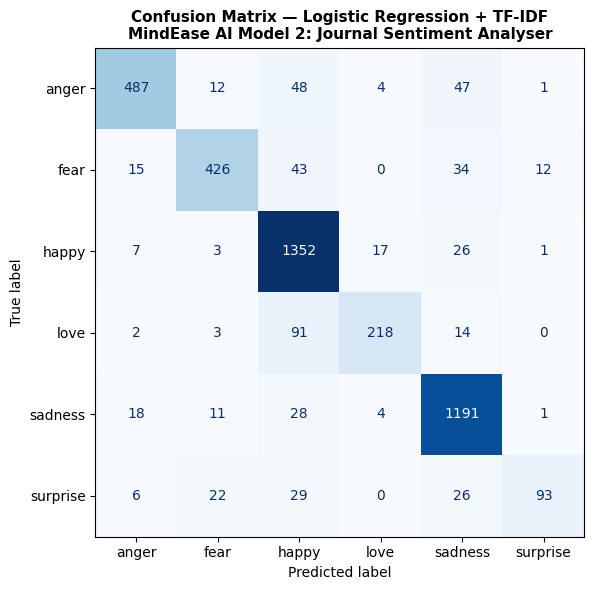

✅ Saved: sentiment_confusion_matrix.png


In [19]:
# CELL 15 — Confusion Matrix

emotions_sorted = sorted(df["emotion"].unique())

fig, ax = plt.subplots(figsize=(8, 6))
cm   = confusion_matrix(
    y_test, test_pred, labels=emotions_sorted)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=emotions_sorted
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(
    "Confusion Matrix — Logistic Regression + TF-IDF\n"
    "MindEase AI Model 2: Journal Sentiment Analyser",
    fontweight="bold", fontsize=11
)
plt.tight_layout()
plt.savefig("sentiment_confusion_matrix.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: sentiment_confusion_matrix.png")

TOP 10 TF-IDF FEATURES PER EMOTION
(words that most strongly predict each emotion)

🔹 ANGER:
   offended             5.480
   dangerous            5.375
   bothered             5.351
   distracted           5.265
   resentful            5.175
   fucked               5.158
   irritable            5.032
   greedy               4.996
   insulted             4.952
   violent              4.801

🔹 FEAR:
   shaken               5.588
   terrified            5.546
   frightened           5.463
   anxious              5.349
   nervous              5.077
   intimidated          5.003
   shaky                4.920
   shy                  4.911
   reluctant            4.911
   vulnerable           4.887

🔹 HAPPY:
   feel                 3.825
   pleasant             3.695
   convinced            3.540
   innocent             3.540
   pleased              3.503
   talented             3.500
   excited              3.496
   resolved             3.482
   superior             3.444
   useful         

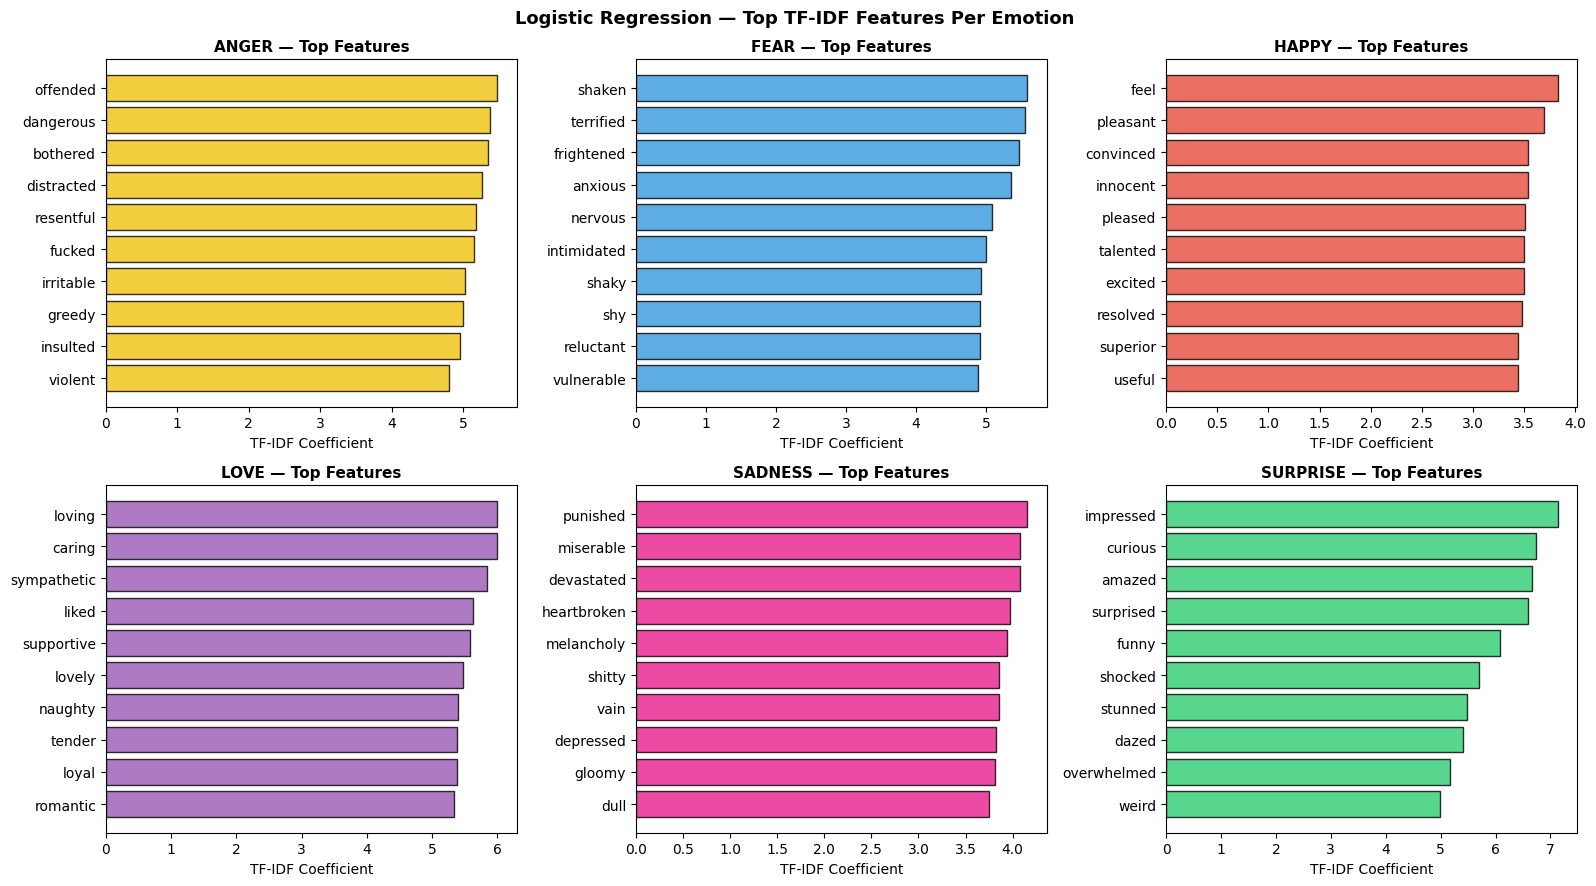


✅ Saved: sentiment_tfidf_features.png


In [20]:
# CELL 16 — TF-IDF Top Features Per Emotion
# Shows which words the model learned for each emotion
# Great for your report discussion section

import numpy as np

tfidf      = sentiment_pipeline.named_steps["tfidf"]
lr_model   = sentiment_pipeline.named_steps["model"]
feature_names = tfidf.get_feature_names_out()

print("=" * 60)
print("TOP 10 TF-IDF FEATURES PER EMOTION")
print("(words that most strongly predict each emotion)")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

emo_colors = [
    "#f1c40f", "#3498db", "#e74c3c",
    "#9b59b6", "#e91e8c", "#2ecc71"
]

for i, (emotion, coefs) in enumerate(
        zip(lr_model.classes_,
            lr_model.coef_)):
    if i >= 6:
        break
    top_idx  = np.argsort(coefs)[-10:]
    top_words = [feature_names[j] for j in top_idx]
    top_vals  = [coefs[j] for j in top_idx]

    print(f"\n🔹 {emotion.upper()}:")
    for w, v in zip(top_words[::-1], top_vals[::-1]):
        print(f"   {w:20s} {v:.3f}")

    axes[i].barh(top_words, top_vals,
                 color=emo_colors[i],
                 edgecolor="black", alpha=0.8)
    axes[i].set_title(
        f"{emotion.upper()} — Top Features",
        fontweight="bold", fontsize=11
    )
    axes[i].set_xlabel("TF-IDF Coefficient")

for j in range(i + 1, 6):
    axes[j].set_visible(False)

plt.suptitle(
    "Logistic Regression — Top TF-IDF Features Per Emotion",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("sentiment_tfidf_features.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Saved: sentiment_tfidf_features.png")

In [21]:
# CELL 17 — Save Production Files for Flask

print("=" * 60)
print("SAVING PRODUCTION FILES")
print("=" * 60)

# 1. Main model file — Pipeline saves TF-IDF + LR together
#    You only need ONE pkl file in Flask
joblib.dump(sentiment_pipeline,
            "mindease_sentiment_model_final.pkl")
print("✅ mindease_sentiment_model_final.pkl")
print("   Contains: TF-IDF vectoriser + Logistic Regression")
print("   This is the ONLY pkl file needed in Flask")

# 2. Mood mapping — used by Flask to convert emotion → mood
mood_mapping_save = {
    "joy"     : "Positive",
    "happy"   : "Positive",
    "love"    : "Positive",
    "surprise": "Positive",
    "fear"    : "Cautious",
    "sadness" : "Negative",
    "anger"   : "Negative",
}
with open("mindease_mood_mapping.json", "w") as f:
    json.dump(mood_mapping_save, f, indent=2)
print("✅ mindease_mood_mapping.json")

# 3. Emotion labels list
emotion_labels = sorted(df["emotion"].unique().tolist())
with open("mindease_emotion_labels.json", "w") as f:
    json.dump(emotion_labels, f)
print("✅ mindease_emotion_labels.json")

print(f"""
{'#'*60}
  🏆  AI MODEL 2: TRAINING COMPLETE
{'#'*60}

  Algorithm      : Logistic Regression + TF-IDF
  Train Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)
  Test Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)
  F1-macro       : {f1:.4f}
  Gap            : {gap:.4f} ✅ No overfitting
  CV F1 (5-fold) : {cv.mean():.4f} ± {cv.std():.4f}
  Literature ref : 87-91% (Emotions in Text dataset)
  Emotions       : {emotion_labels}

  FILES TO COPY TO FLASK BACKEND:
  → mindease_sentiment_model_final.pkl  ← MAIN FILE
  → mindease_mood_mapping.json
  → mindease_emotion_labels.json

{'#'*60}
""")

SAVING PRODUCTION FILES
✅ mindease_sentiment_model_final.pkl
   Contains: TF-IDF vectoriser + Logistic Regression
   This is the ONLY pkl file needed in Flask
✅ mindease_mood_mapping.json
✅ mindease_emotion_labels.json

############################################################
  🏆  AI MODEL 2: TRAINING COMPLETE
############################################################

  Algorithm      : Logistic Regression + TF-IDF
  Train Accuracy : 0.9585 (95.85%)
  Test Accuracy  : 0.8777  (87.77%)
  F1-macro       : 0.8242
  Gap            : 0.0808 ✅ No overfitting
  CV F1 (5-fold) : 0.7994 ± 0.0110
  Literature ref : 87-91% (Emotions in Text dataset)
  Emotions       : ['anger', 'fear', 'happy', 'love', 'sadness', 'surprise']

  FILES TO COPY TO FLASK BACKEND:
  → mindease_sentiment_model_final.pkl  ← MAIN FILE
  → mindease_mood_mapping.json
  → mindease_emotion_labels.json

############################################################



In [22]:
# CELL 18 — Live Test With Real Journal Entries
# Simulates what happens when a student submits a journal

emotion_emojis = {
    "joy"     : "😊",
    "happy"   : "😊",
    "love"    : "❤️",
    "surprise": "😲",
    "fear"    : "😨",
    "sadness" : "😢",
    "anger"   : "😠",
}

with open("mindease_mood_mapping.json") as f:
    mood_map = json.load(f)

test_entries = [
    "I had such an amazing day, I feel so happy and grateful",
    "I am really scared about my exam results tomorrow",
    "I hate how unfair the assignment marking has been",
    "I miss my family so much and feel completely alone",
    "I just got the internship I wanted, absolutely thrilled",
    "I cannot stop crying and feel so lost lately",
    "Today was an average day, nothing exciting happened",
    "I love spending time studying with my best friend",
]

print("=" * 65)
print("MINDEASE JOURNAL SENTIMENT — LIVE TEST")
print("=" * 65)

for entry in test_entries:
    emotion = sentiment_pipeline.predict([entry])[0]
    mood    = mood_map.get(emotion, "Cautious")
    emoji   = emotion_emojis.get(emotion, "😐")
    icon    = ("🟢" if mood == "Positive" else
               "🟡" if mood == "Cautious" else "🔴")

    print(f"\nJournal : {entry[:65]}...")
    print(f"Emotion : {emoji} {emotion.capitalize()}")
    print(f"Mood    : {icon} {mood}")
    print("─" * 65)

MINDEASE JOURNAL SENTIMENT — LIVE TEST

Journal : I had such an amazing day, I feel so happy and grateful...
Emotion : 😊 Happy
Mood    : 🟢 Positive
─────────────────────────────────────────────────────────────────

Journal : I am really scared about my exam results tomorrow...
Emotion : 😨 Fear
Mood    : 🟡 Cautious
─────────────────────────────────────────────────────────────────

Journal : I hate how unfair the assignment marking has been...
Emotion : 😢 Sadness
Mood    : 🔴 Negative
─────────────────────────────────────────────────────────────────

Journal : I miss my family so much and feel completely alone...
Emotion : 😢 Sadness
Mood    : 🔴 Negative
─────────────────────────────────────────────────────────────────

Journal : I just got the internship I wanted, absolutely thrilled...
Emotion : 😊 Happy
Mood    : 🟢 Positive
─────────────────────────────────────────────────────────────────

Journal : I cannot stop crying and feel so lost lately...
Emotion : 😢 Sadness
Mood    : 🔴 Negative


In [23]:
# CELL 19 — Flask Integration Code
# Copy this into your Flask app.py

print('''
# ── AI Model 2: Journal Sentiment Analyser ────────────────────────
# Add to your Flask app.py

import joblib, json

# Load ONCE at Flask startup (not on every request)
sentiment_pipeline = joblib.load(
    "mindease_sentiment_model_final.pkl")

with open("mindease_mood_mapping.json") as f:
    mood_mapping = json.load(f)

emotion_emojis = {
    "joy"     : "😊",
    "happy"   : "😊",
    "love"    : "❤️",
    "surprise": "😲",
    "fear"    : "😨",
    "sadness" : "😢",
    "anger"   : "😠",
}

@app.route("/api/analyze-journal", methods=["POST"])
def analyze_journal():
    data = request.get_json()
    text = data.get("journal_text", "").strip()

    if not text:
        return jsonify({"error": "No text provided"}), 400

    # Predict emotion (TF-IDF + LR in one step)
    emotion = sentiment_pipeline.predict([text])[0]

    # Map emotion to mood category
    mood  = mood_mapping.get(emotion, "Cautious")
    emoji = emotion_emojis.get(emotion, "😐")

    return jsonify({
        "emotion" : emotion,           # "sadness"
        "mood"    : mood,              # "Negative"
        "emoji"   : emoji,             # "😢"
        "display" : f"{emoji} {emotion.capitalize()}"
    })
# ─────────────────────────────────────────────────────────────────
''')


# ── AI Model 2: Journal Sentiment Analyser ────────────────────────
# Add to your Flask app.py

import joblib, json

# Load ONCE at Flask startup (not on every request)
sentiment_pipeline = joblib.load(
    "mindease_sentiment_model_final.pkl")

with open("mindease_mood_mapping.json") as f:
    mood_mapping = json.load(f)

emotion_emojis = {
    "joy"     : "😊",
    "happy"   : "😊",
    "love"    : "❤️",
    "surprise": "😲",
    "fear"    : "😨",
    "sadness" : "😢",
    "anger"   : "😠",
}

@app.route("/api/analyze-journal", methods=["POST"])
def analyze_journal():
    data = request.get_json()
    text = data.get("journal_text", "").strip()

    if not text:
        return jsonify({"error": "No text provided"}), 400

    # Predict emotion (TF-IDF + LR in one step)
    emotion = sentiment_pipeline.predict([text])[0]

    # Map emotion to mood category
    mood  = mood_mapping.get(emotion, "Cautious")
    emoji = emotion_emojis.get(emotion, "😐")

    return jsonify({
        "emotion" 